In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

DATA_DIR    = Path('data')
RESULTS_DIR = Path('results')

final_pairs = pd.read_csv(RESULTS_DIR / 'final_candidate_pairs.csv')

prices = pd.read_csv(
    DATA_DIR / 'sp500_190_16y_adjclose_ffill.csv',
    index_col=0, parse_dates=True
)

needed    = list(set(final_pairs.stock1.tolist() + final_pairs.stock2.tolist()))
log_prices = np.log(prices[needed])

print(f"Pairs loaded    : {len(final_pairs)}")
print(f"Unique tickers  : {len(needed)}")
final_pairs[['stock1', 'stock2', 'stability']]


Pairs loaded    : 19
Unique tickers  : 31


,stock1,stock2,stability
0,MA,UBER,0.240000
1,UBER,ECL,0.213333
2,SYK,INTU,0.212435
3,ORCL,PWR,0.202073
4,HON,SHW,0.202073
5,ABNB,APD,0.200000
6,TXN,SPGI,0.196891
7,CRM,CI,0.196891
8,HON,SYK,0.196891
9,MCK,DELL,0.190909


In [2]:
def kalman_hedge_ratio(y, x, delta=1e-5, warmup=120):
    n = len(y)
    Q = (delta / (1.0 - delta)) * np.eye(2)

   
    b0 = np.cov(y[:504], x[:504])[0, 1] / np.var(x[:504])
    a0 = np.mean(y[:504]) - b0 * np.mean(x[:504])
    R  = float(np.var(y[:504] - b0 * x[:504] - a0))

    state    = np.zeros((n, 2))
    P        = np.zeros((n, 2, 2))
    state[0] = [b0, a0]
    P[0]     = np.eye(2)

    for t in range(1, n):
        H      = np.array([x[t], 1.0])
        s_pred = state[t - 1]
        P_pred = P[t - 1] + Q

        innov = y[t] - H @ s_pred
        S     = float(H @ P_pred @ H + R)

        
        if abs(S) < 1e-10:
            S = 1e-10

        K = (P_pred @ H) / S

        state[t] = s_pred + K * innov
        P[t]     = (np.eye(2) - np.outer(K, H)) @ P_pred

    beta_t  = state[:, 0].copy()
    alpha_t = state[:, 1].copy()
    P_beta  = P[:, 0, 0].copy()
    spread  = y - beta_t * x - alpha_t

    
    beta_t[:warmup]  = np.nan
    alpha_t[:warmup] = np.nan
    spread[:warmup]  = np.nan

    return beta_t, alpha_t, P_beta, spread


In [3]:
MIN_OBS = 504 + 120   

records    = []
pair_cache = {}

for idx, row in final_pairs.iterrows():
    s1, s2 = row['stock1'], row['stock2']

    common = log_prices[[s1, s2]].dropna()
    if len(common) < MIN_OBS:
        print(f"Skipped {s1}/{s2} — only {len(common)} obs")
        continue

    y     = common[s1].values
    x     = common[s2].values
    b_ols = np.cov(y, x)[0, 1] / np.var(x)

    beta_t, alpha_t, P_beta, spread = kalman_hedge_ratio(y, x)

    pair_cache[(s1, s2)] = {
        'dates'     : common.index,
        'beta'      : beta_t,
        'alpha'     : alpha_t,
        'P_beta'    : P_beta,
        'spread'    : spread,
        'beta_ols'  : b_ols,
        'stability' : row['stability'],
    }

    for i, date in enumerate(common.index):
        records.append({
            'stock1'    : s1,
            'stock2'    : s2,
            'date'      : date,
            'beta_kf'   : beta_t[i],
            'alpha_kf'  : alpha_t[i],
            'P_beta'    : P_beta[i],
            'spread_kf' : spread[i],
            'stability' : row['stability'],
        })

df_kf = pd.DataFrame(records)
df_kf.to_csv(RESULTS_DIR / 'kalman_dynamic_spreads.csv', index=False)
print(f"Pairs processed : {len(pair_cache)}")
print(f"Total rows      : {len(df_kf):,}")
print(f"Saved → results/kalman_dynamic_spreads.csv")
df_kf.head()


Pairs processed : 19
Total rows      : 63,923
Saved → results/kalman_dynamic_spreads.csv


,stock1,stock2,date,beta_kf,alpha_kf,P_beta,spread_kf,stability
0,MA,UBER,2019-05-10,NaN,NaN,1.000000,NaN,0.24
1,MA,UBER,2019-05-13,NaN,NaN,0.071756,NaN,0.24
2,MA,UBER,2019-05-14,NaN,NaN,0.068695,NaN,0.24
3,MA,UBER,2019-05-15,NaN,NaN,0.066272,NaN,0.24
4,MA,UBER,2019-05-16,NaN,NaN,0.063090,NaN,0.24


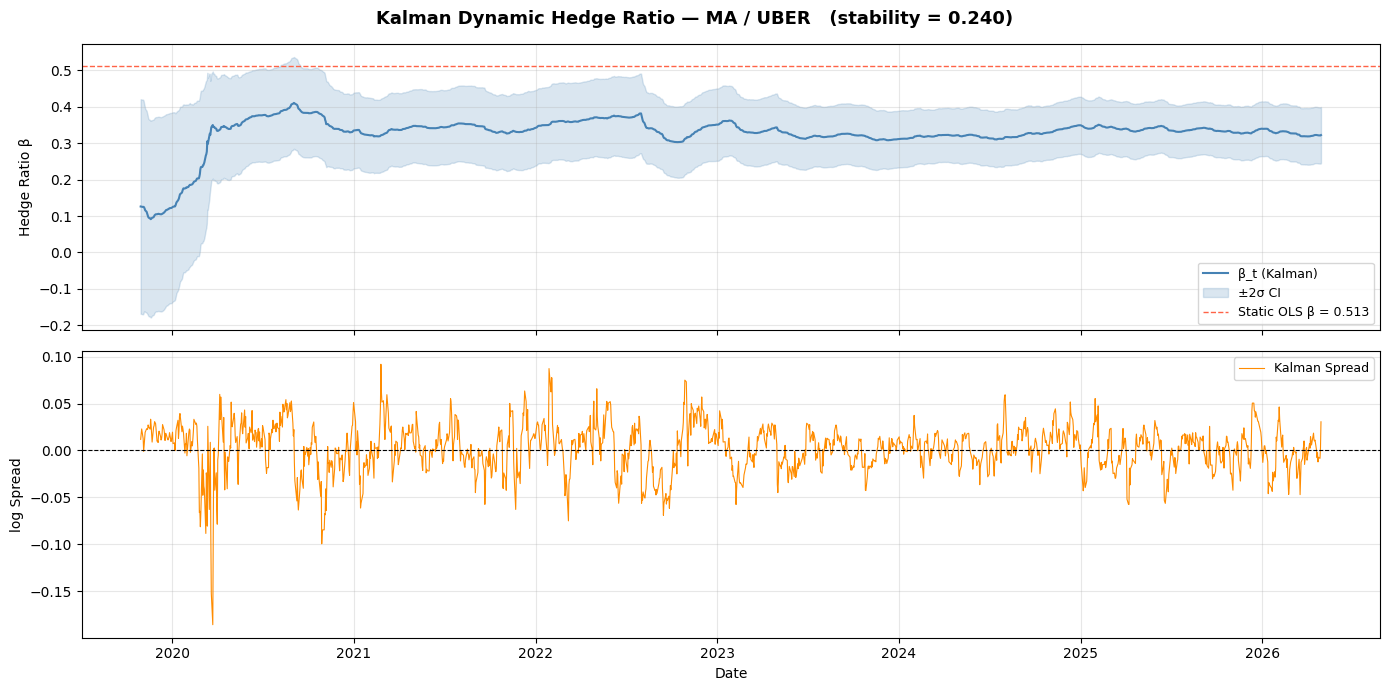

1/19 — MA/UBER saved


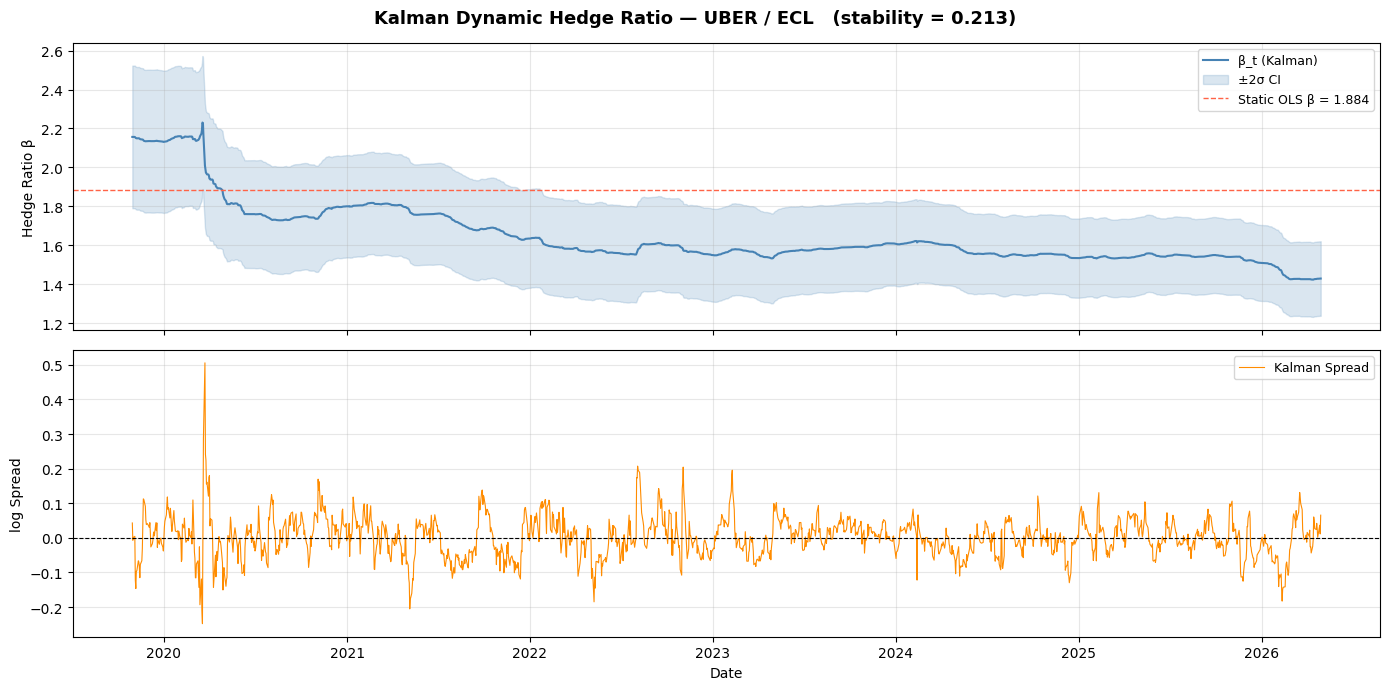

2/19 — UBER/ECL saved


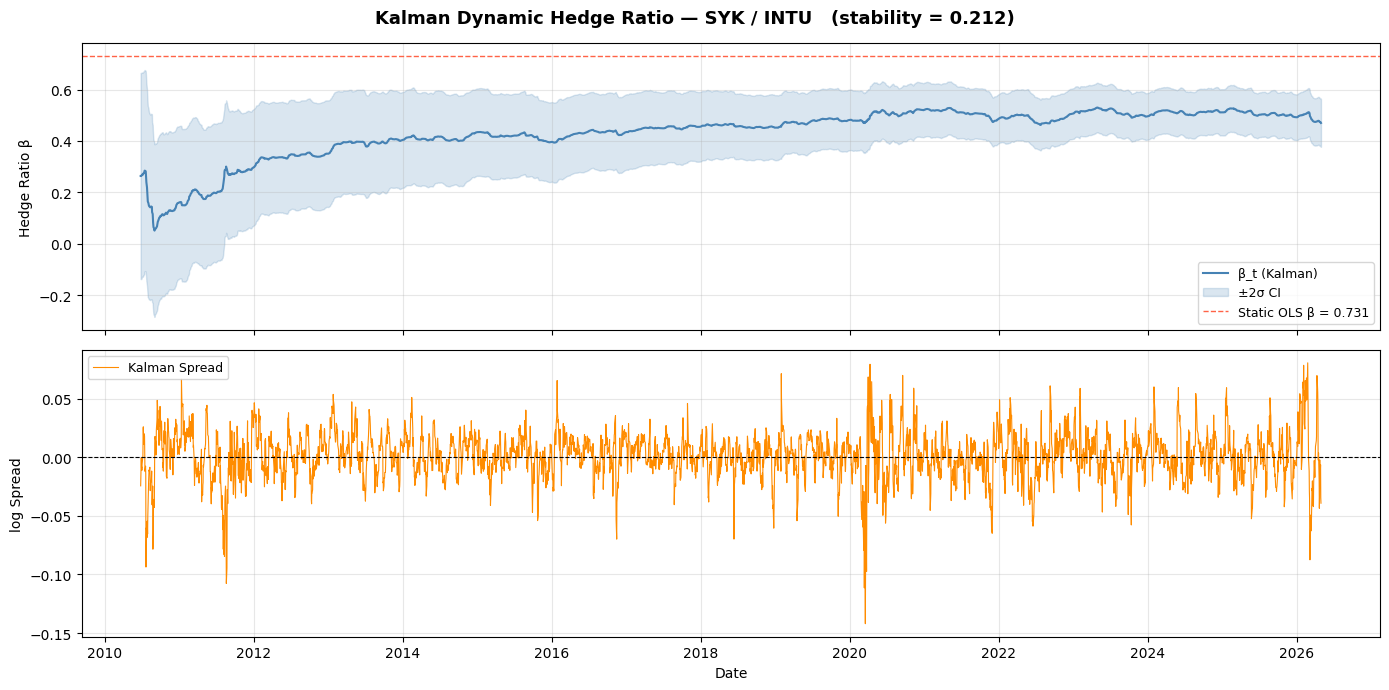

3/19 — SYK/INTU saved


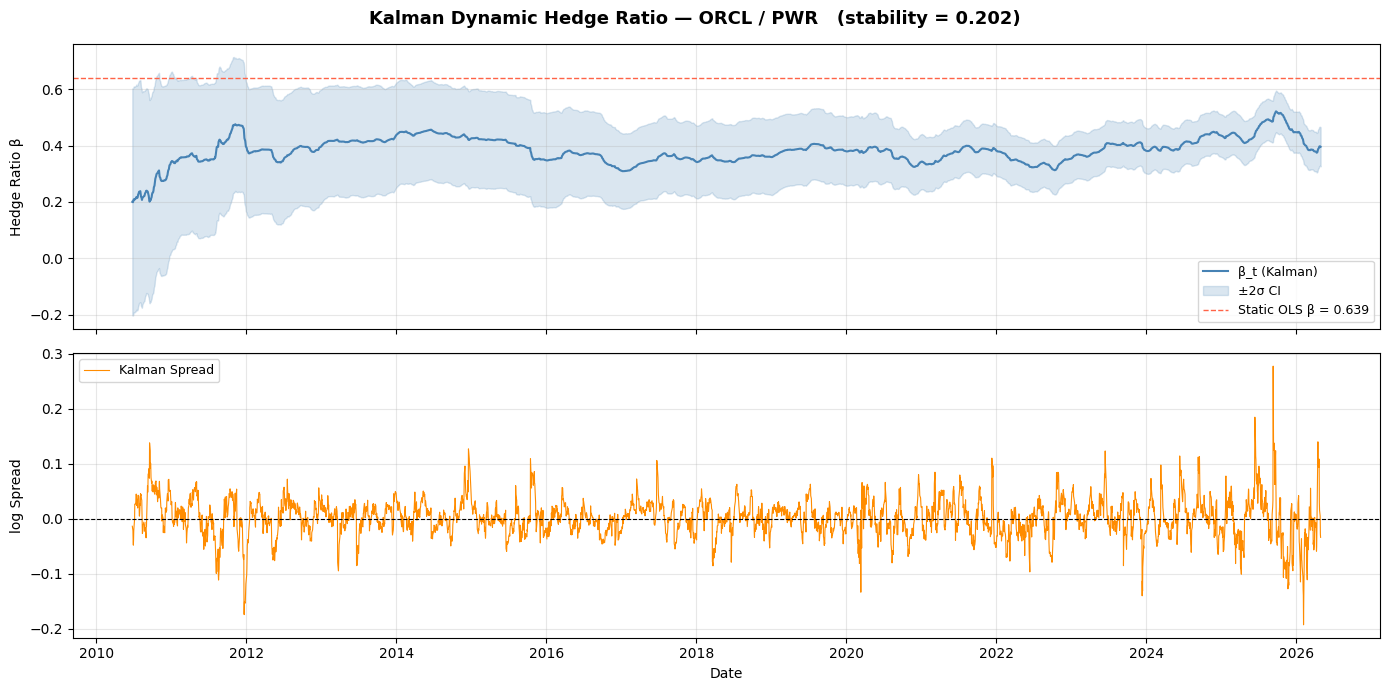

4/19 — ORCL/PWR saved


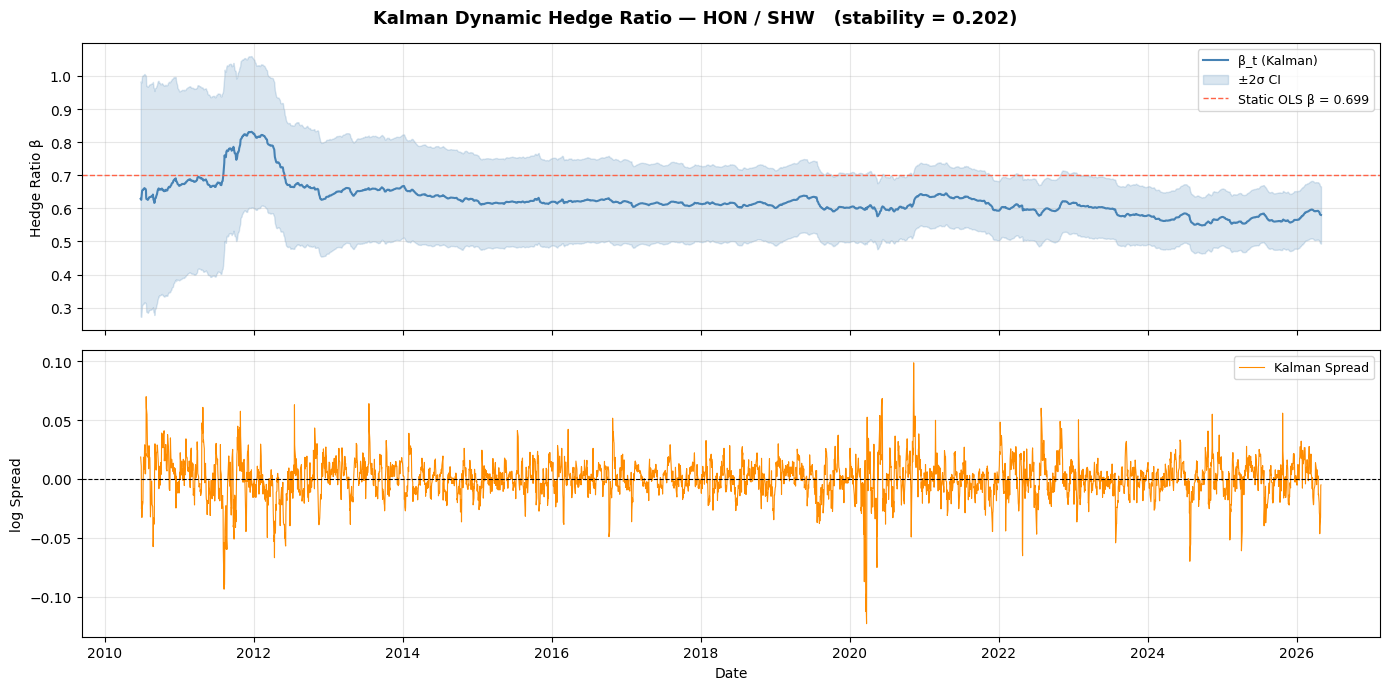

5/19 — HON/SHW saved


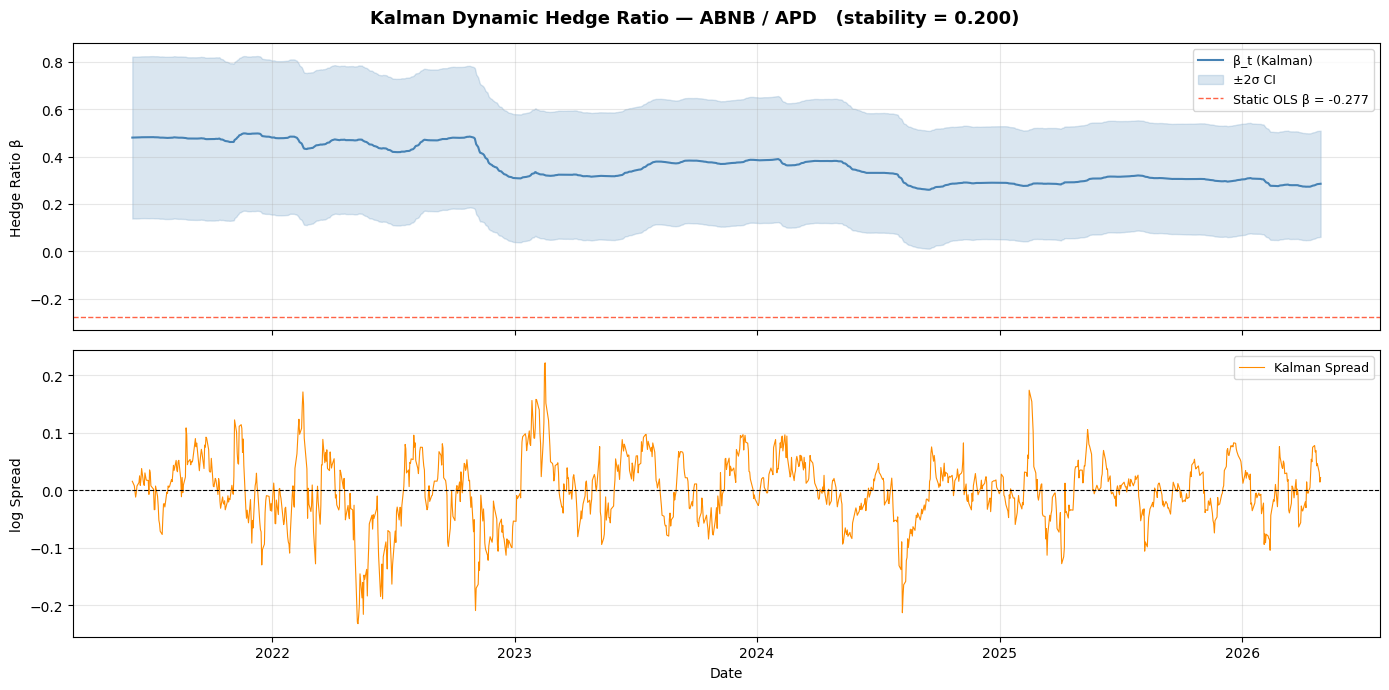

6/19 — ABNB/APD saved


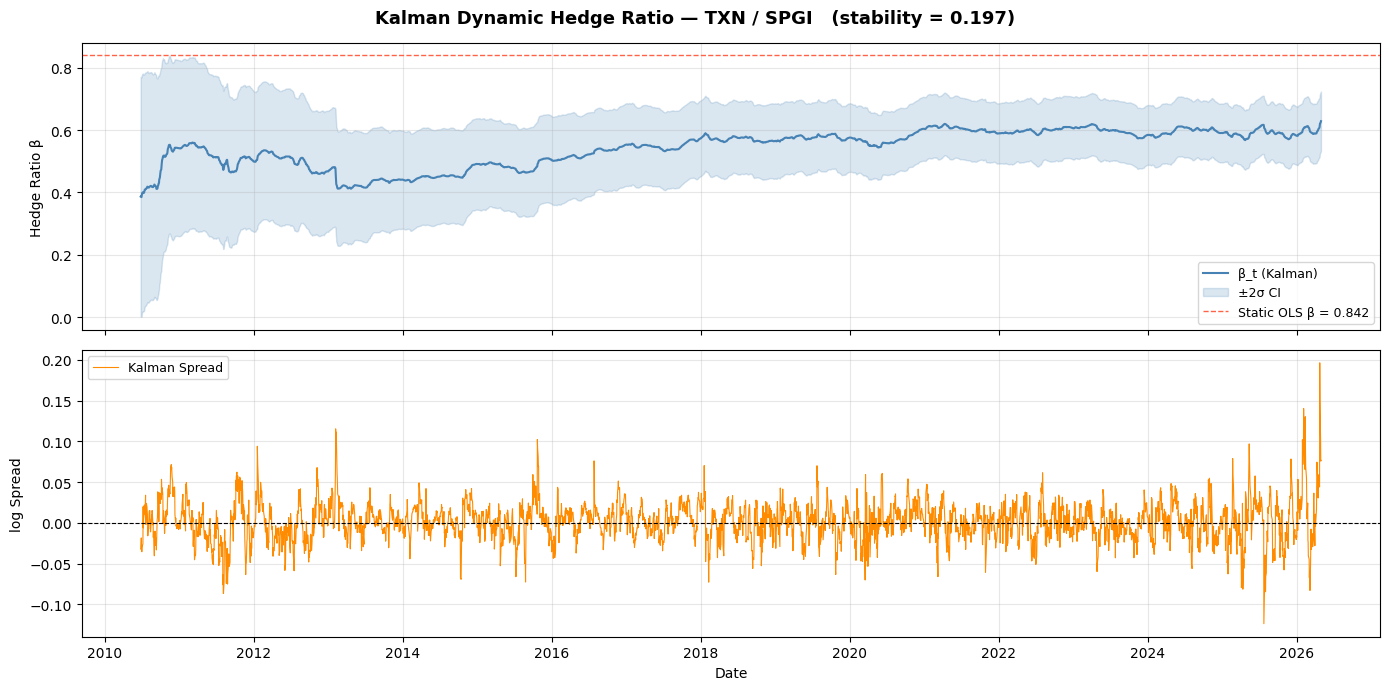

7/19 — TXN/SPGI saved


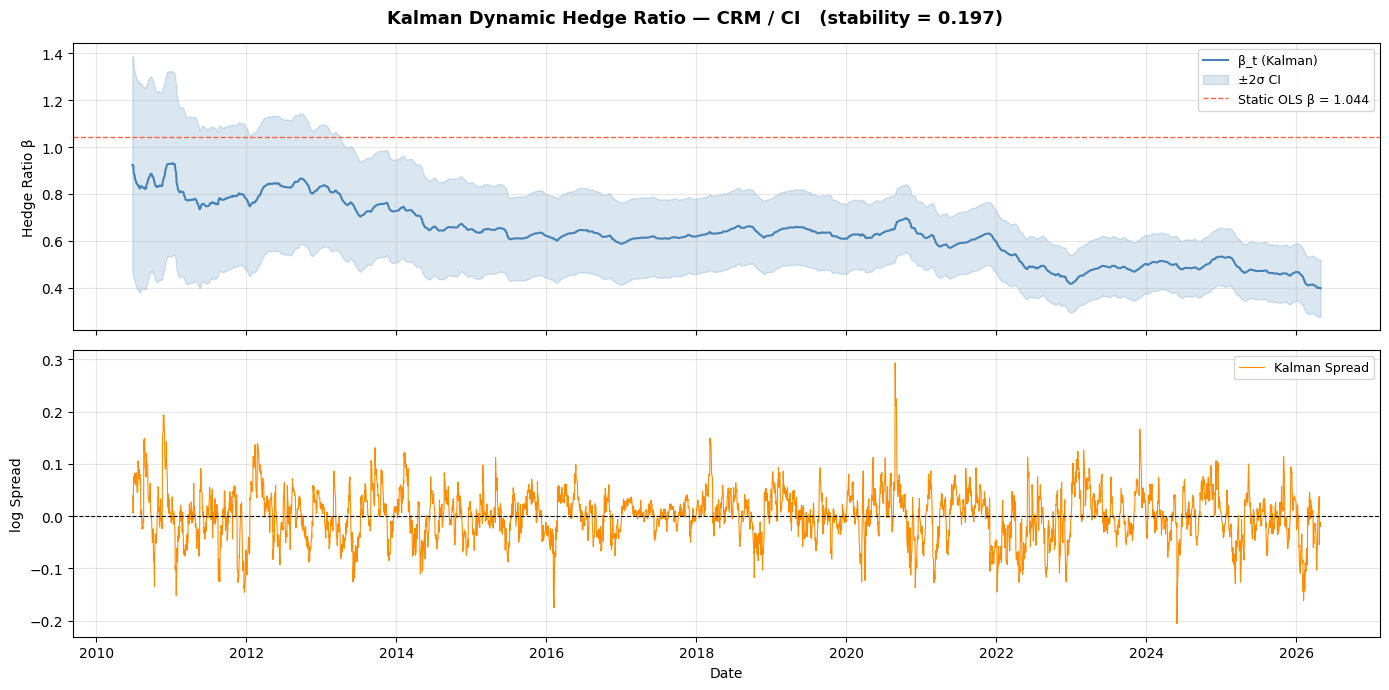

8/19 — CRM/CI saved


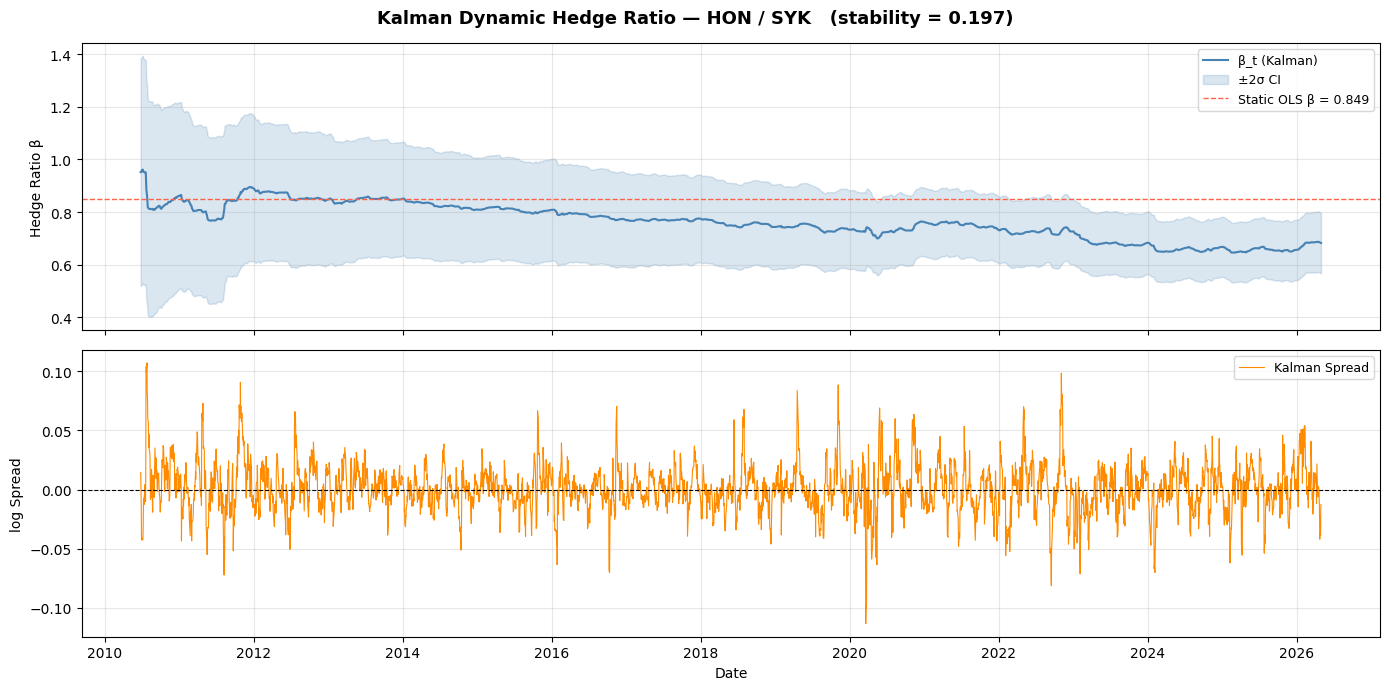

9/19 — HON/SYK saved


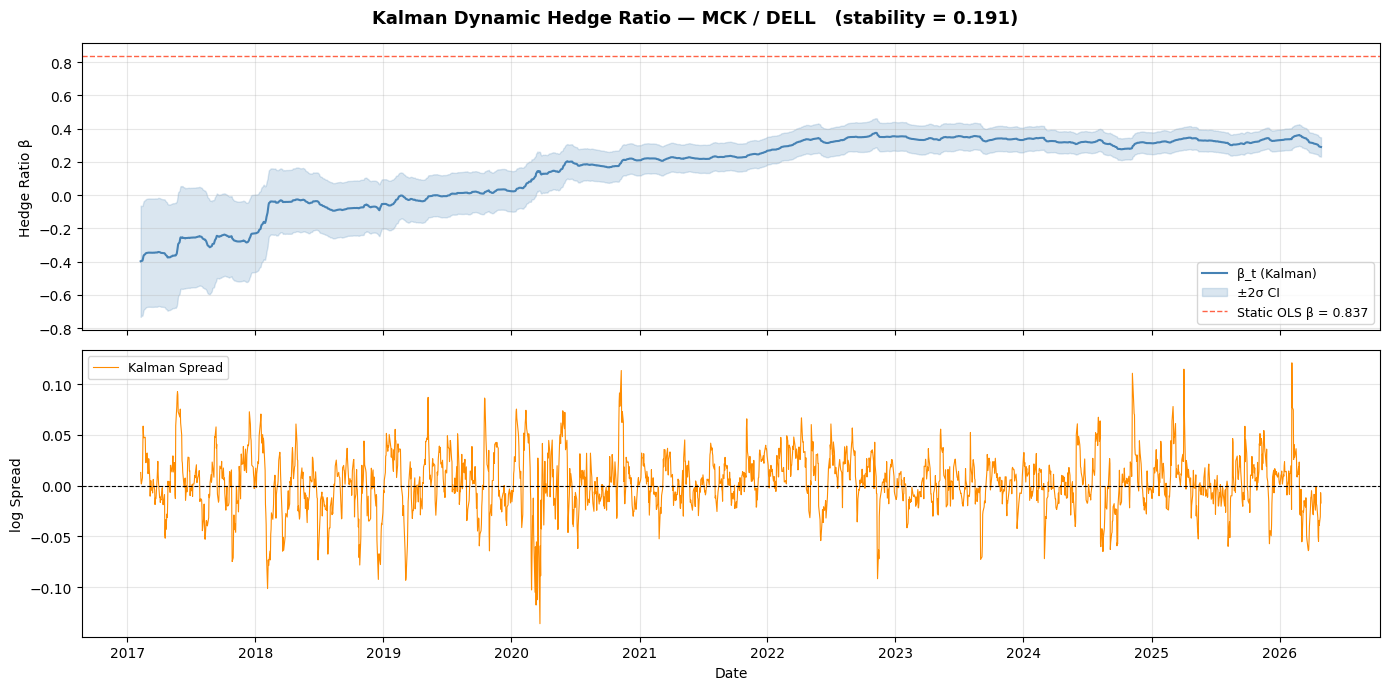

10/19 — MCK/DELL saved


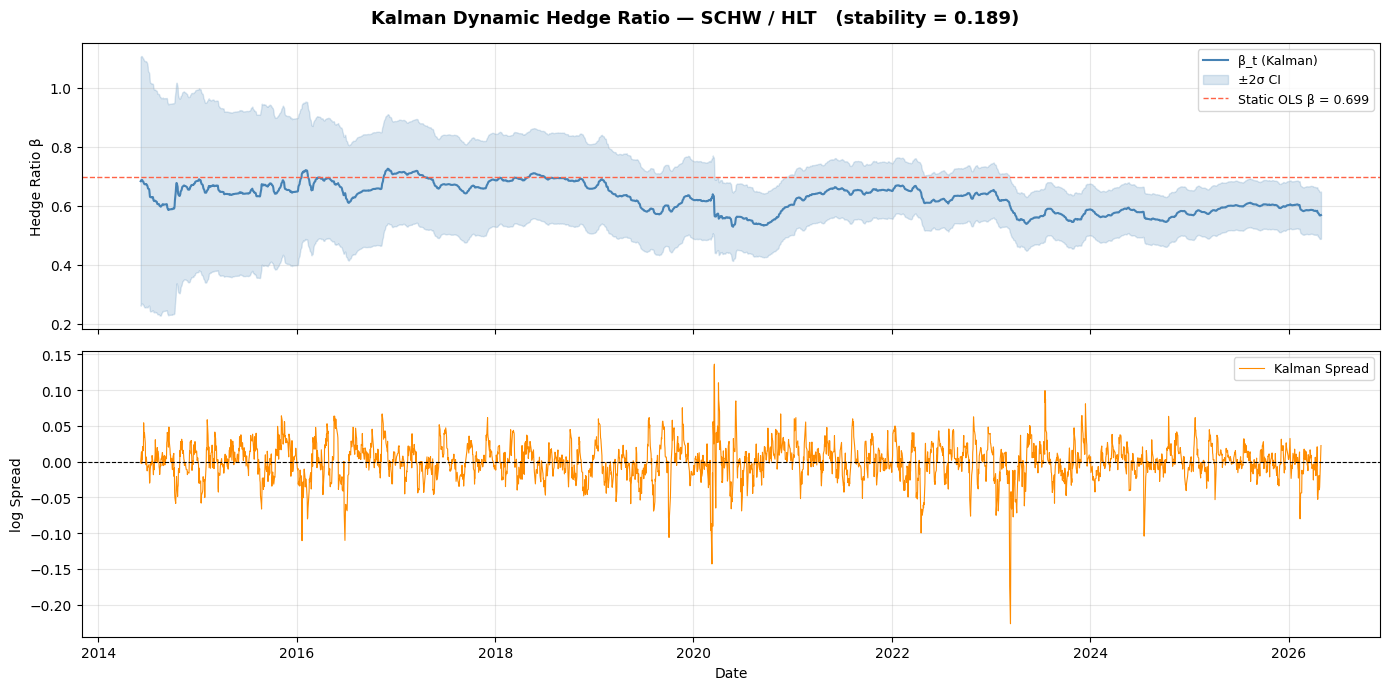

11/19 — SCHW/HLT saved


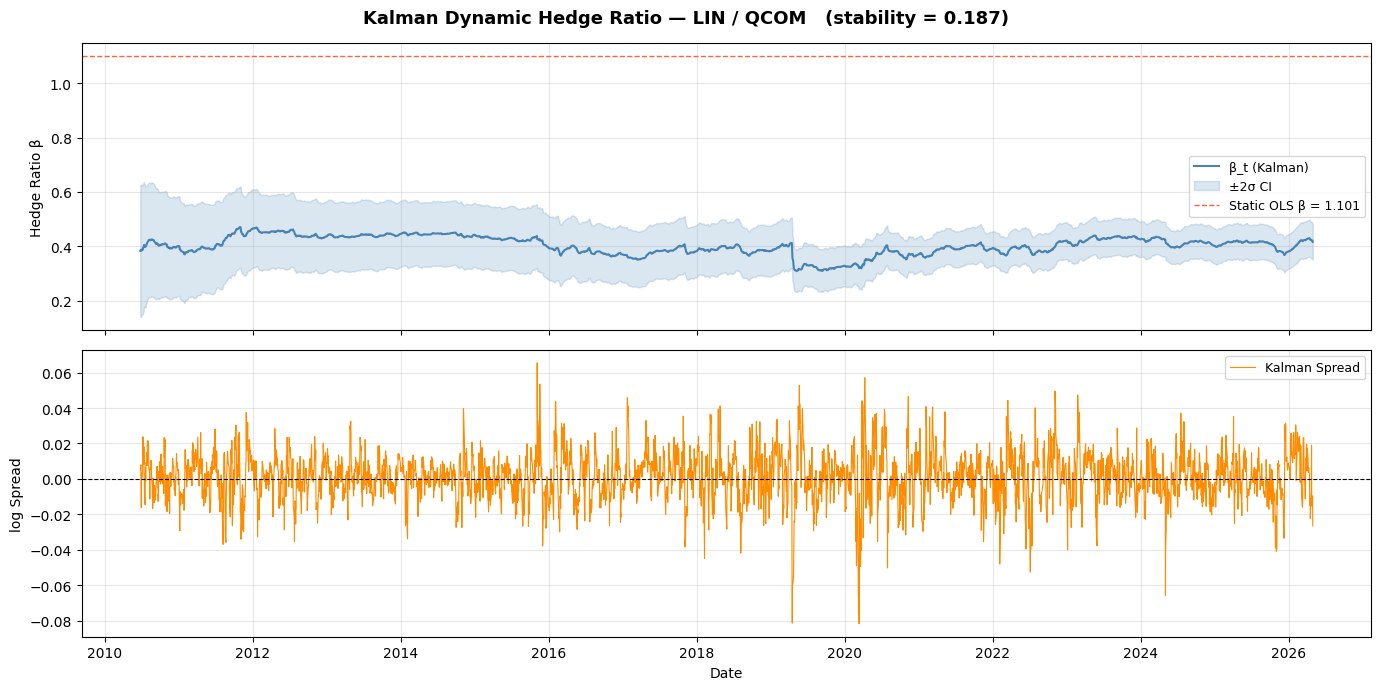

12/19 — LIN/QCOM saved


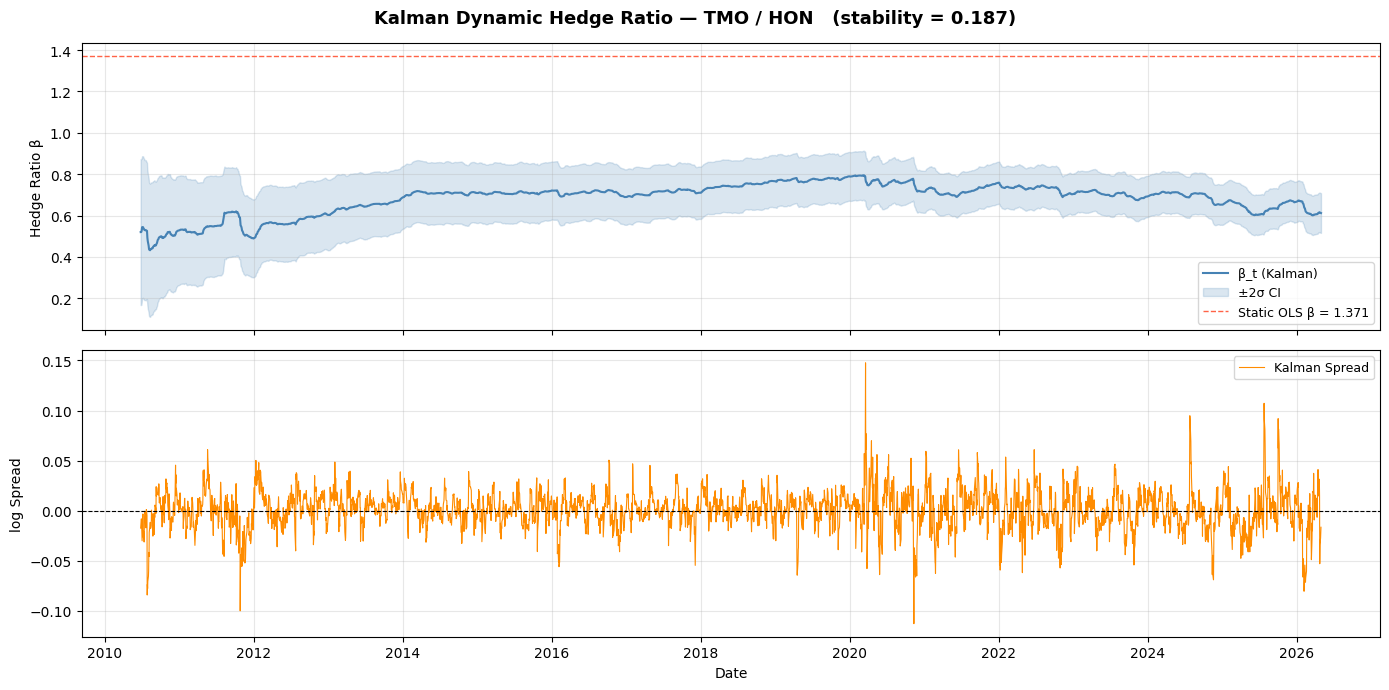

13/19 — TMO/HON saved


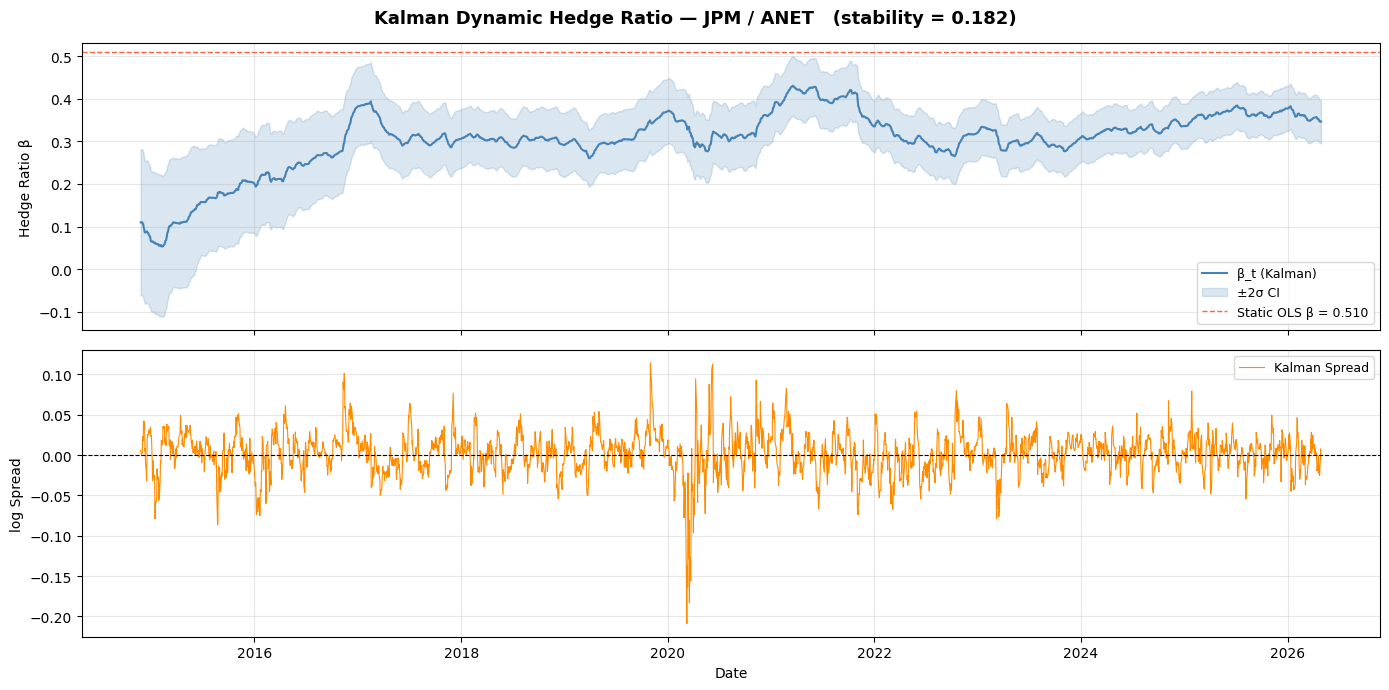

14/19 — JPM/ANET saved


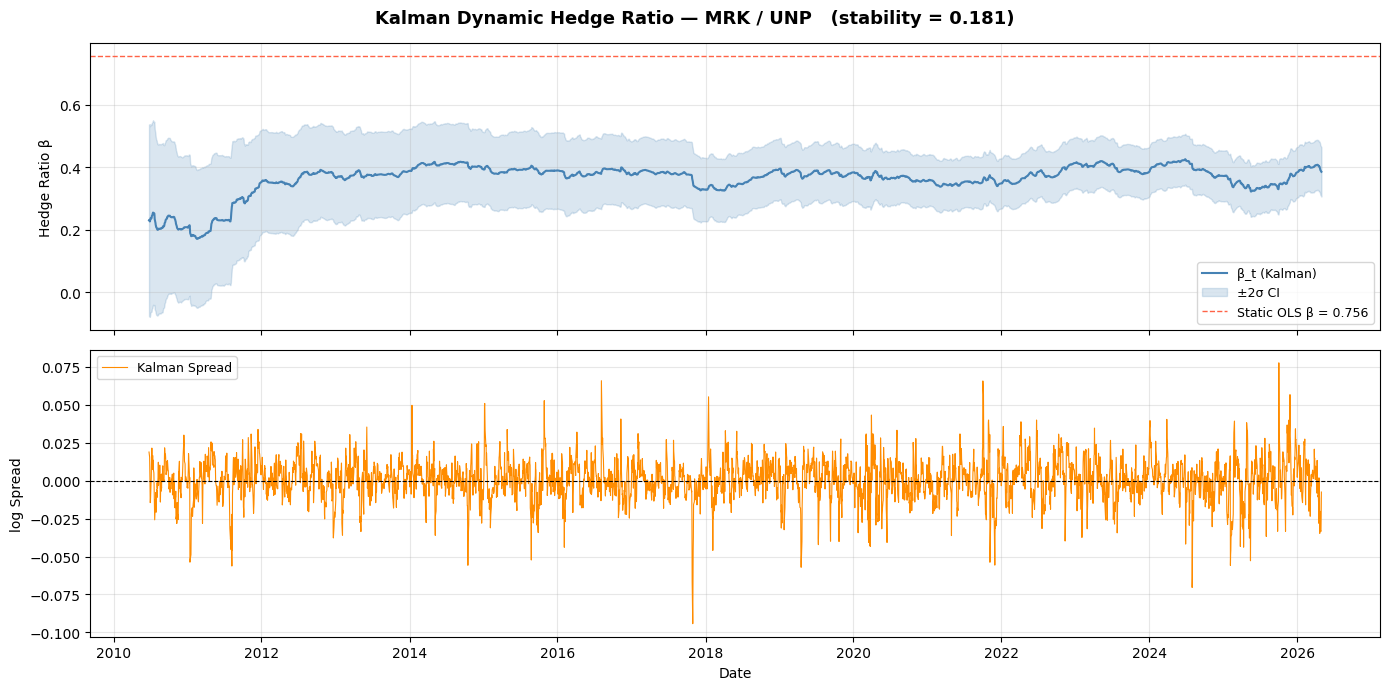

15/19 — MRK/UNP saved


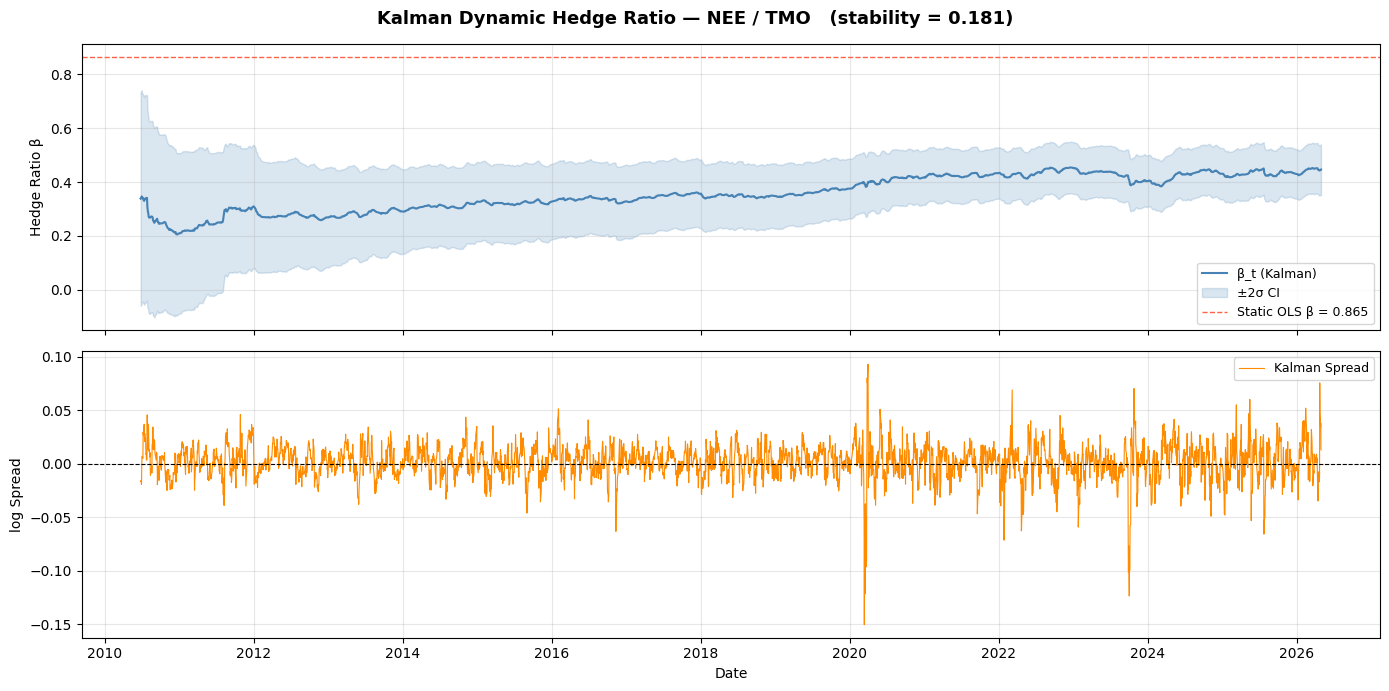

16/19 — NEE/TMO saved


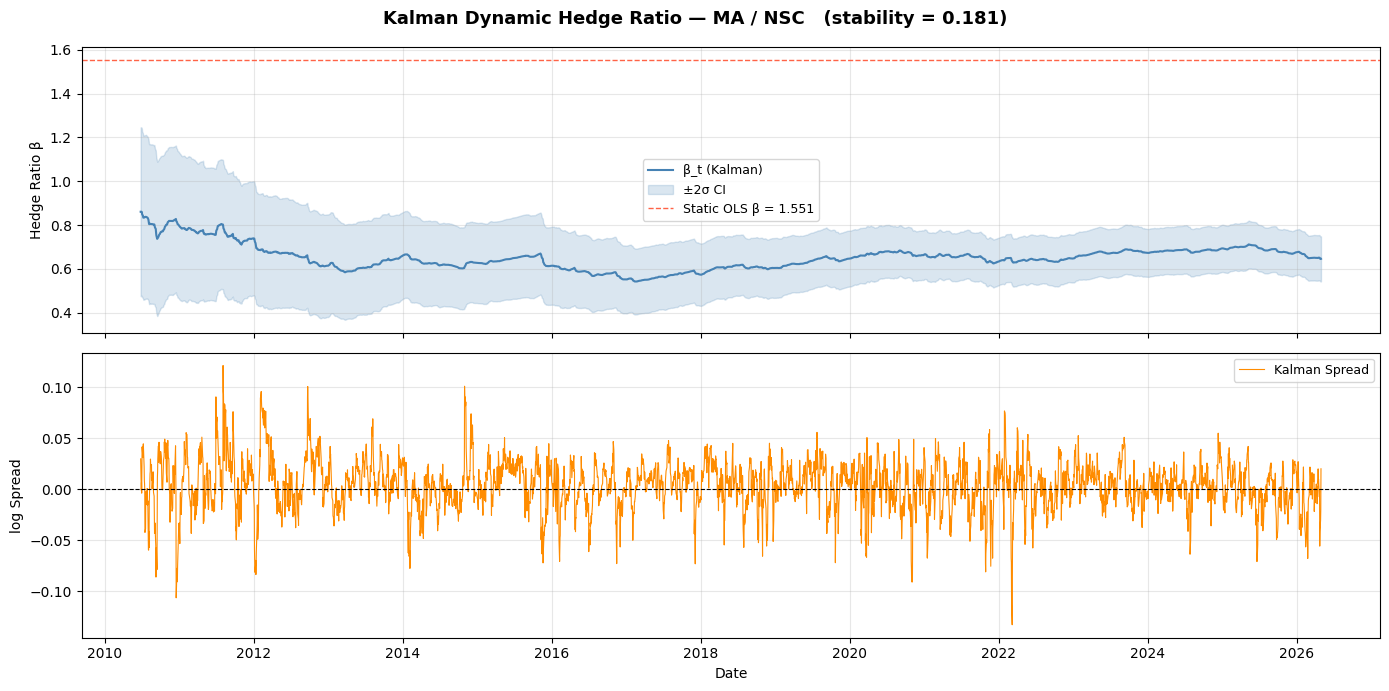

17/19 — MA/NSC saved


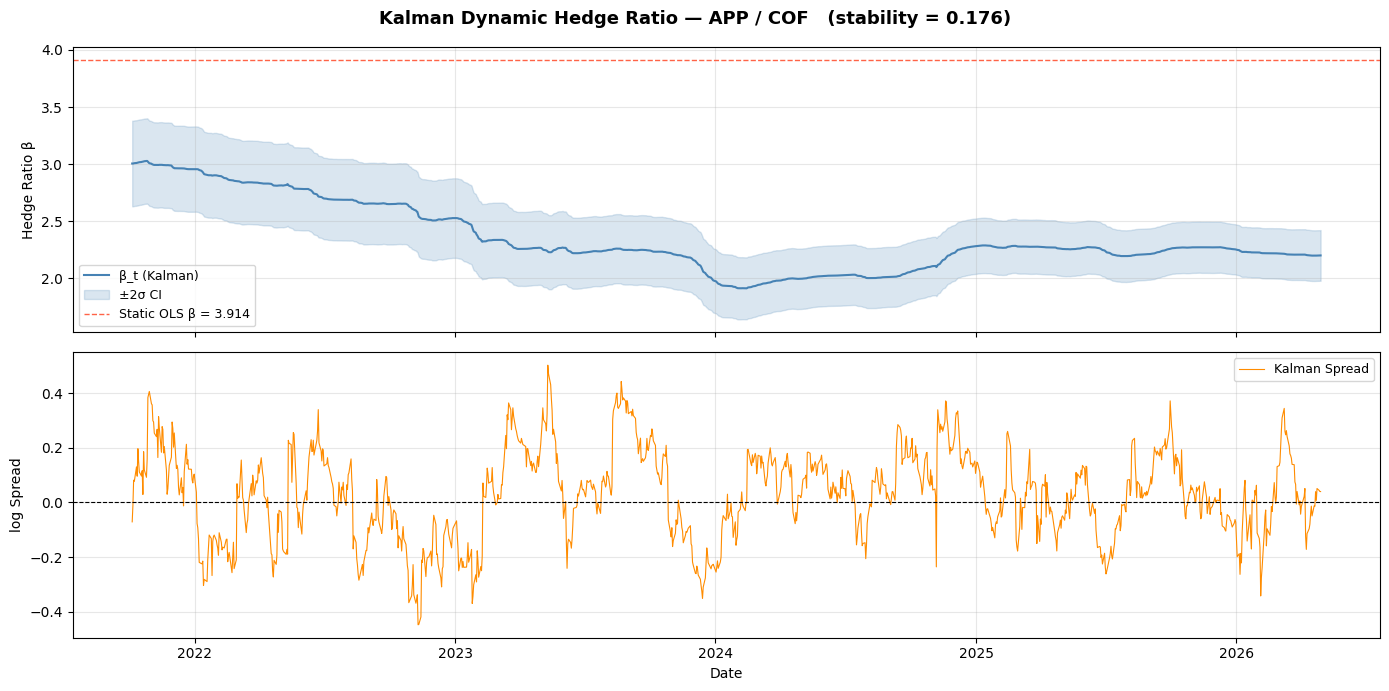

18/19 — APP/COF saved


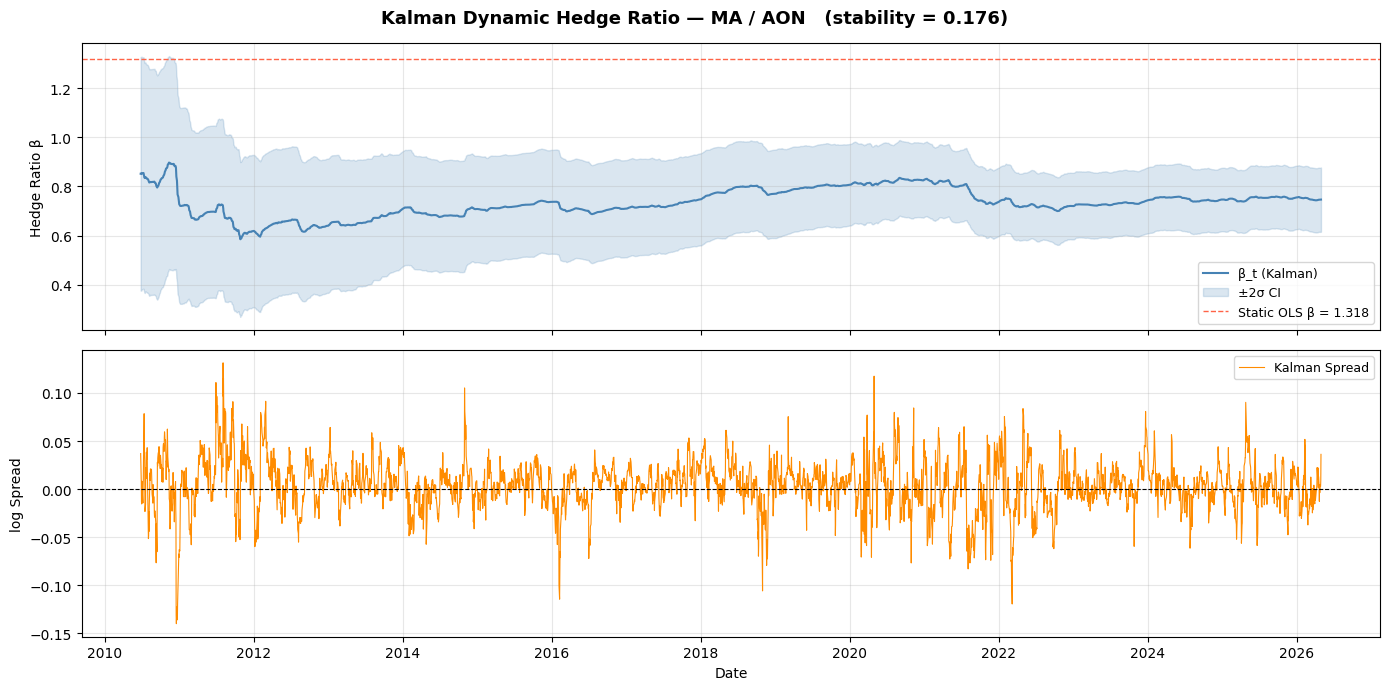

19/19 — MA/AON saved


In [4]:
for idx, ((s1, s2), kf) in enumerate(pair_cache.items()):
    dates  = kf['dates']
    beta   = kf['beta']
    b_ols  = kf['beta_ols']
    spread = kf['spread']
    ci_up  = beta + 2 * np.sqrt(kf['P_beta'])
    ci_lo  = beta - 2 * np.sqrt(kf['P_beta'])

    fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)
    fig.suptitle(
        f'Kalman Dynamic Hedge Ratio — {s1} / {s2}   '
        f'(stability = {kf["stability"]:.3f})',
        fontsize=13, fontweight='bold'
    )

    ax = axes[0]
    ax.plot(dates, beta, color='steelblue', lw=1.5, label='β_t (Kalman)')
    ax.fill_between(dates, ci_lo, ci_up, alpha=0.2, color='steelblue', label='±2σ CI')
    ax.axhline(b_ols, color='tomato', lw=1, ls='--', label=f'Static OLS β = {b_ols:.3f}')
    ax.set_ylabel('Hedge Ratio β')
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)

    ax = axes[1]
    ax.plot(dates, spread, color='darkorange', lw=0.8, label='Kalman Spread')
    ax.axhline(0, color='black', lw=0.8, ls='--')
    ax.set_ylabel('log Spread')
    ax.set_xlabel('Date')
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

    plt.tight_layout()
    plt.savefig(RESULTS_DIR / f'kalman_{s1}_{s2}.png', dpi=130, bbox_inches='tight')
    plt.show()
    plt.close()
    print(f"{idx+1}/{len(pair_cache)} — {s1}/{s2} saved")


In [5]:
rows = []
for (s1, s2), kf in pair_cache.items():
    b = kf['beta'][~np.isnan(kf['beta'])]
    rows.append({
        'stock1'     : s1,
        'stock2'     : s2,
        'stability'  : kf['stability'],
        'beta_ols'   : round(kf['beta_ols'], 4),
        'beta_mean'  : round(b.mean(), 4),
        'beta_std'   : round(b.std(), 4),
        'beta_min'   : round(b.min(), 4),
        'beta_max'   : round(b.max(), 4),
        'beta_range' : round(b.max() - b.min(), 4),
    })

df_summary = pd.DataFrame(rows).sort_values('stability', ascending=False)
df_summary.to_csv(RESULTS_DIR / 'kalman_beta_summary.csv', index=False)
print("Saved → results/kalman_beta_summary.csv\n")
df_summary


Saved → results/kalman_beta_summary.csv



,stock1,stock2,stability,beta_ols,beta_mean,beta_std,beta_min,beta_max,beta_range
0,MA,UBER,0.240000,0.5133,0.3278,0.0486,0.0913,0.4105,0.3192
1,UBER,ECL,0.213333,1.8840,1.6503,0.1612,1.4242,2.2305,0.8063
2,SYK,INTU,0.212435,0.7309,0.4330,0.0939,0.0509,0.5304,0.4796
3,ORCL,PWR,0.202073,0.6385,0.3828,0.0460,0.1991,0.5212,0.3222
4,HON,SHW,0.202073,0.6994,0.6246,0.0490,0.5483,0.8314,0.2831
5,ABNB,APD,0.200000,-0.2769,0.3657,0.0738,0.2599,0.4981,0.2382
6,TXN,SPGI,0.196891,0.8415,0.5428,0.0575,0.3849,0.6285,0.2437
7,CRM,CI,0.196891,1.0445,0.6299,0.1171,0.3980,0.9307,0.5327
8,HON,SYK,0.196891,0.8492,0.7631,0.0662,0.6459,0.9608,0.3148
9,MCK,DELL,0.190909,0.8368,0.1582,0.2084,-0.3976,0.3747,0.7722
